<a href="https://colab.research.google.com/github/SKSAHILAKHTAR1/AI-Powered-SDR-Laboratory/blob/main/Pulse_Shaping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

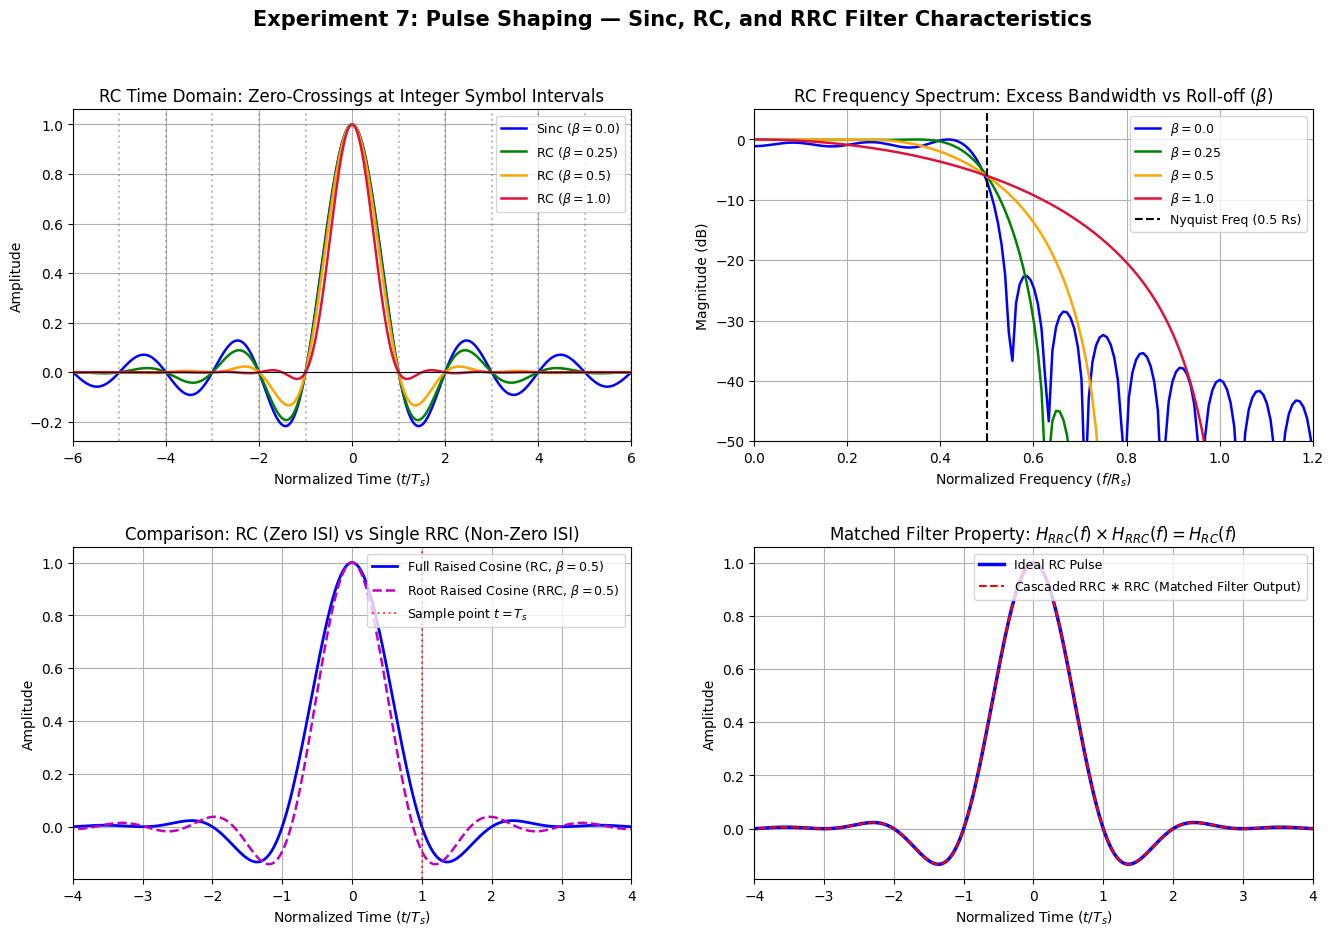

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ====================================================================
# 1. PARAMETERS
# ====================================================================
Rs = 1.0                # Symbol rate (1 symbol/sec)
Ts = 1.0 / Rs           # Symbol duration
sps = 32                # Samples per symbol (oversampling factor)
fs = sps * Rs           # Sampling rate (Hz)
span = 6                # Pulse duration span in symbols (-span to +span)

# High-resolution time vector
t = np.arange(-span * Ts, span * Ts + 1/fs, 1/fs)

# Roll-off factors to evaluate
beta_values = [0.0, 0.25, 0.5, 1.0]

# ====================================================================
# 2. FILTER IMPULSE RESPONSES
# ====================================================================
def get_rc_pulse(t, Ts, beta):
    """Raised Cosine (RC) pulse."""
    t_safe = np.copy(t)
    # Avoid division by zero at singularity points t = +/- Ts / (2*beta)
    if beta > 0:
        singularities = np.isclose(np.abs(t_safe), Ts / (2 * beta))
        t_safe[singularities] += 1e-10

    numerator = np.sinc(t_safe / Ts) * np.cos(np.pi * beta * t_safe / Ts)
    denominator = 1.0 - (2.0 * beta * t_safe / Ts) ** 2
    return numerator / denominator

def get_rrc_pulse(t, Ts, beta):
    """Root-Raised Cosine (RRC) pulse."""
    t_safe = np.copy(t)
    pulse = np.zeros_like(t_safe)

    for i, ti in enumerate(t_safe):
        if np.isclose(ti, 0.0):
            pulse[i] = 1.0 - beta + (4.0 * beta / np.pi)
        elif beta > 0 and np.isclose(np.abs(ti), Ts / (4.0 * beta)):
            pulse[i] = (beta / np.sqrt(2)) * (
                (1 + 2 / np.pi) * np.sin(np.pi / (4 * beta)) +
                (1 - 2 / np.pi) * np.cos(np.pi / (4 * beta))
            )
        else:
            num = np.sin(np.pi * ti * (1 - beta) / Ts) + 4 * beta * (ti / Ts) * np.cos(np.pi * ti * (1 + beta) / Ts)
            den = (np.pi * ti / Ts) * (1 - (4 * beta * ti / Ts) ** 2)
            pulse[i] = num / den
    return pulse / np.max(pulse)

# ====================================================================
# 3. COMPREHENSIVE 4-PANEL VISUALIZATION
# ====================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plt.subplots_adjust(hspace=0.32, wspace=0.22)
fig.suptitle("Experiment 7: Pulse Shaping — Sinc, RC, and RRC Filter Characteristics", fontsize=15, fontweight='bold')

colors = ['blue', 'green', 'orange', 'crimson']

# --- Panel 1: Raised Cosine (RC) Impulse Responses ---
for beta, c in zip(beta_values, colors):
    h_rc = get_rc_pulse(t, Ts, beta)
    label = r"Sinc ($\beta=0.0$)" if beta == 0 else rf"RC ($\beta={beta}$)"
    axes[0, 0].plot(t / Ts, h_rc, color=c, lw=1.8, label=label)

# Highlight Zero-ISI sampling grid
for k in range(-span, span + 1):
    if k != 0:
        axes[0, 0].axvline(k, color='gray', linestyle=':', alpha=0.5)
axes[0, 0].axhline(0, color='black', lw=0.8)
axes[0, 0].set_title("RC Time Domain: Zero-Crossings at Integer Symbol Intervals", fontsize=12)
axes[0, 0].set_xlabel(r"Normalized Time ($t / T_s$)")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].set_xlim(-span, span)
axes[0, 0].grid(True)
axes[0, 0].legend(loc='upper right', fontsize=9)

# --- Panel 2: RC Frequency Response (Magnitude Spectrum) ---
N_fft = 4096
freqs = np.fft.rfftfreq(N_fft, d=1/fs)
norm_freqs = freqs / Rs  # Normalize to symbol rate

for beta, c in zip(beta_values, colors):
    h_rc = get_rc_pulse(t, Ts, beta)
    H_rc = np.abs(np.fft.rfft(h_rc, n=N_fft))
    H_rc_db = 20 * np.log10(H_rc / np.max(H_rc) + 1e-12)
    label = r"$\beta=0.0$" if beta == 0 else rf"$\beta={beta}$"
    axes[0, 1].plot(norm_freqs, H_rc_db, color=c, lw=1.8, label=label)

axes[0, 1].axvline(0.5, color='black', linestyle='--', label="Nyquist Freq (0.5 Rs)")
axes[0, 1].set_title(r"RC Frequency Spectrum: Excess Bandwidth vs Roll-off ($\beta$)", fontsize=12)
axes[0, 1].set_xlabel(r"Normalized Frequency ($f / R_s$)")
axes[0, 1].set_ylabel("Magnitude (dB)")
axes[0, 1].set_xlim(0, 1.2)
axes[0, 1].set_ylim(-50, 5)
axes[0, 1].grid(True)
axes[0, 1].legend(loc='upper right', fontsize=9)

# --- Panel 3: RC vs RRC Impulse Response (for beta=0.5) ---
test_beta = 0.5
h_rc_test = get_rc_pulse(t, Ts, test_beta)
h_rrc_test = get_rrc_pulse(t, Ts, test_beta)

axes[1, 0].plot(t / Ts, h_rc_test, 'b-', lw=2, label=rf"Full Raised Cosine (RC, $\beta={test_beta}$)")
axes[1, 0].plot(t / Ts, h_rrc_test, 'm--', lw=1.8, label=rf"Root Raised Cosine (RRC, $\beta={test_beta}$)")

# Mark non-zero ISI of single RRC filter
axes[1, 0].axvline(1.0, color='red', linestyle=':', alpha=0.7, label=r"Sample point $t=T_s$")
axes[1, 0].set_title(r"Comparison: RC (Zero ISI) vs Single RRC (Non-Zero ISI)", fontsize=12)
axes[1, 0].set_xlabel(r"Normalized Time ($t / T_s$)")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].set_xlim(-4, 4)
axes[1, 0].grid(True)
axes[1, 0].legend(loc='upper right', fontsize=9)

# --- Panel 4: Matched Filtering (RRC * RRC = RC) ---
# Convolve Tx RRC filter with Rx RRC filter
h_conv = np.convolve(h_rrc_test, h_rrc_test, mode='same')
h_conv = h_conv / np.max(h_conv)

axes[1, 1].plot(t / Ts, h_rc_test, 'b-', lw=2.5, label="Ideal RC Pulse")
axes[1, 1].plot(t / Ts, h_conv, 'r--', lw=1.5, label=r"Cascaded RRC $\ast$ RRC (Matched Filter Output)")
axes[1, 1].set_title(r"Matched Filter Property: $H_{RRC}(f) \times H_{RRC}(f) = H_{RC}(f)$", fontsize=12)
axes[1, 1].set_xlabel(r"Normalized Time ($t / T_s$)")
axes[1, 1].set_ylabel("Amplitude")
axes[1, 1].set_xlim(-4, 4)
axes[1, 1].grid(True)
axes[1, 1].legend(loc='upper right', fontsize=9)

plt.show()